<a href="https://colab.research.google.com/github/kpate18/ECGR-4105/blob/main/homework%204/Problem_2.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

Training samples: 436
Testing samples: 109

Kernel: linear
R2 Score: 0.6179926468396819
RMSE: 1389562.1616807138
MAE: 1000478.3434790418

Kernel: poly
R2 Score: 0.5414983437257423
RMSE: 1522343.2036536701
MAE: 1090739.2040394093

Kernel: rbf
R2 Score: 0.596950549705773
RMSE: 1427319.7817128599
MAE: 1049354.944669734

Kernel: sigmoid
R2 Score: -2.1769160901693683
RMSE: 4007236.6469365875
MAE: 2607715.26328996


<Figure size 800x500 with 0 Axes>

<Figure size 800x500 with 0 Axes>

<Figure size 800x500 with 0 Axes>

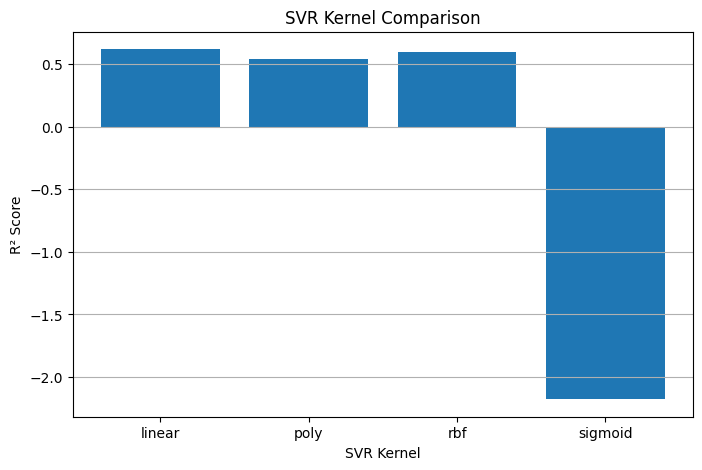

In [2]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt

from sklearn.model_selection import train_test_split
from sklearn.preprocessing import StandardScaler
from sklearn.svm import SVR
from sklearn.linear_model import Ridge

from sklearn.metrics import (
    mean_squared_error,
    mean_absolute_error,
    r2_score
)

df = pd.read_csv("Housing.csv")

df.head()

yes_no_columns = [
    "mainroad",
    "guestroom",
    "basement",
    "hotwaterheating",
    "airconditioning",
    "prefarea"
]

for column in yes_no_columns:
    df[column] = df[column].map({
        "yes": 1,
        "no": 0
    })

features = [
    "area",
    "bedrooms",
    "bathrooms",
    "stories",
    "mainroad",
    "guestroom",
    "basement",
    "hotwaterheating",
    "airconditioning",
    "parking",
    "prefarea"
]

X = df[features]

y = df["price"]

X_train, X_test, y_train, y_test = train_test_split(
    X,
    y,
    test_size=0.20,
    random_state=42
)

print("Training samples:", len(X_train))
print("Testing samples:", len(X_test))

X_scaler = StandardScaler()
y_scaler = StandardScaler()

X_train_scaled = X_scaler.fit_transform(X_train)
X_test_scaled = X_scaler.transform(X_test)

y_train_scaled = y_scaler.fit_transform(
    y_train.values.reshape(-1, 1)
).ravel()

kernels = ["linear", "poly", "rbf", "sigmoid"]

r2_scores = []
rmse_scores = []
mae_scores = []

for kernel in kernels:

    model = SVR(kernel=kernel)

    model.fit(X_train_scaled, y_train_scaled)

    prediction_scaled = model.predict(X_test_scaled)

    predictions = y_scaler.inverse_transform(
        prediction_scaled.reshape(-1, 1)
    ).ravel()

    r2 = r2_score(y_test, predictions)

    rmse = np.sqrt(
        mean_squared_error(y_test, predictions)
    )

    mae = mean_absolute_error(
        y_test,
        predictions
    )

    r2_scores.append(r2)
    rmse_scores.append(rmse)
    mae_scores.append(mae)

    print("\nKernel:", kernel)
    print("R2 Score:", r2)
    print("RMSE:", rmse)
    print("MAE:", mae)

    plt.figure(figsize=(8, 5))

plt.bar(kernels, r2_scores)

plt.xlabel("SVR Kernel")
plt.ylabel("R² Score")
plt.title("SVR Kernel Comparison")

plt.grid(axis="y")

plt.show()


Best kernel: linear


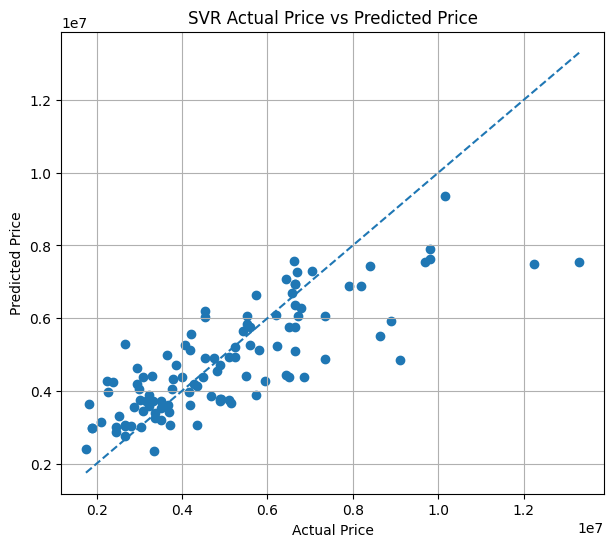

In [4]:
best_index = np.argmax(r2_scores)

best_kernel = kernels[best_index]

print("Best kernel:", best_kernel)

best_svr = SVR(kernel=best_kernel)

best_svr.fit(
    X_train_scaled,
    y_train_scaled
)

prediction_scaled = best_svr.predict(
    X_test_scaled
)

best_predictions = y_scaler.inverse_transform(
    prediction_scaled.reshape(-1, 1)
).ravel()

plt.figure(figsize=(7, 6))

plt.scatter(
    y_test,
    best_predictions
)

minimum = min(
    y_test.min(),
    best_predictions.min()
)

maximum = max(
    y_test.max(),
    best_predictions.max()
)

plt.plot(
    [minimum, maximum],
    [minimum, maximum],
    "--"
)

plt.xlabel("Actual Price")
plt.ylabel("Predicted Price")

plt.title(
    "SVR Actual Price vs Predicted Price"
)

plt.grid()

plt.show()

Ridge R2: 0.6436130800834199
Ridge RMSE: 1342155.9974914


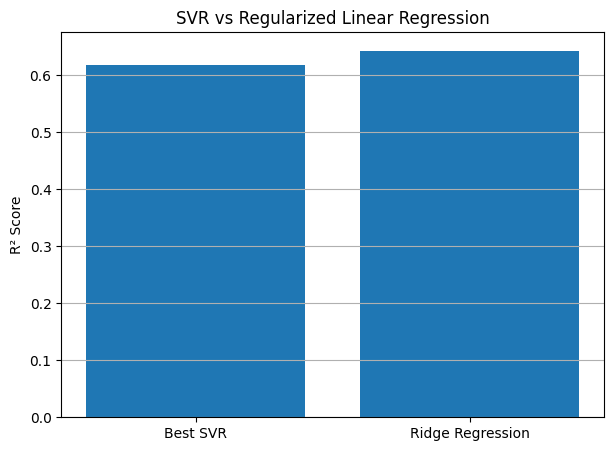

In [5]:
ridge_model = Ridge(alpha=1.0)

ridge_model.fit(
    X_train_scaled,
    y_train
)

ridge_predictions = ridge_model.predict(
    X_test_scaled
)

ridge_r2 = r2_score(
    y_test,
    ridge_predictions
)

ridge_rmse = np.sqrt(
    mean_squared_error(
        y_test,
        ridge_predictions
    )
)

print("Ridge R2:", ridge_r2)
print("Ridge RMSE:", ridge_rmse)

best_svr_r2 = max(r2_scores)

models = [
    "Best SVR",
    "Ridge Regression"
]

scores = [
    best_svr_r2,
    ridge_r2
]

plt.figure(figsize=(7, 5))

plt.bar(models, scores)

plt.ylabel("R² Score")
plt.title("SVR vs Regularized Linear Regression")

plt.grid(axis="y")

plt.show()